# Configurações

In [3]:
# Extensão que verifica se um dos arquivos foi alterado
%load_ext autoreload
%autoreload 2

In [23]:
from c3_1_instance_reweighing import instance_reweighing  # É preciso começar por ele para não dar problema com o torch vindo da aif360

# Bibliotecas
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from tabulate import tabulate
import traceback
import time
import os
from contextlib import contextmanager

# Variáveis auxiliares
from c0_configuracoes import(
  seed,
  colunas_discretas1,
  colunas_discretas2,
  colunas_discretas3,
  colunas_discretas4,
  param_grid_perceptron_basico,
  param_grid_random_forest_basico,
  param_grid_regressao_logistica_basico,
  param_grid_xgboost_basico,
  param_grid_perceptron_completo,
  param_grid_random_forest_completo,
  param_grid_regressao_logistica_completo,
  param_grid_xgboost_completo,
  dados_sensiveis_age,
  dados_sensiveis_sexo,
  preprocessor_passthrough
)

# Funções auxiliares
from c1_2_smote import enviesamento_smotenc_rotulo_binario as enviesamento_smotenc
from c1_3_preprocessor_automatizado import aplicar_pre_processador

# Algoritmos
from c2_1_random_forest import random_forest_GSCV
from c2_2_xgboost import xgboost_GSCV
from c2_3_regressao_logistica import regressao_logistica_GSCV
from c2_4_perceptron import perceptron_GSCV

# Técnicas de pré-processamento
from c3_1_instance_reweighing import instance_reweighing
from c3_2_disparate_impact_removal import disparate_impact_removal
from c3_3_synthetic_data_generation import synthetic_data_generation
from c3_4_suppression import suppression

# Técnicas de pós-processamento
from c4_1_threshold_optimization import threshold_optimization
from c4_2_calibration import calibration
from c4_3_reject_option_classification import reject_option_classification

# Enviesando

In [5]:
# Enviesando os datasets
datasets = {
    'df1':{
        'original': {
        'nome_banco': "DATASET 1 ORIGINAL",
        'data': pd.read_csv(f"Datasets/Processados/Dataset1.csv", sep=','),
        'colunas_discretas': colunas_discretas1,
        }
    },
    'df2':{
        'original': {
        'nome_banco': "DATASET 2 ORIGINAL",
        'data': pd.read_csv(f"Datasets/Processados/Dataset2.csv", sep=','),
        'colunas_discretas': colunas_discretas2,
        }
    },
    'df3':{
        'original': {
        'nome_banco': "DATASET 3 ORIGINAL",
        'data': pd.read_csv(f"Datasets/Processados/Dataset3.csv", sep=','),
        'colunas_discretas': colunas_discretas3,
        }
    },
    'df4':{
        'original': {
        'nome_banco': "DATASET 4 ORIGINAL",
        'data': pd.read_csv(f"Datasets/Processados/Dataset4.csv", sep=','),
        'colunas_discretas': colunas_discretas4,
        }
    }
}

# As classes fazem referência a como o smote será aplicado
variaveis_sensiveis = {
  'sensitive_sexo': {
    'classe_alterada': 1,                   # Aultera o número de mulheres
    'classe_intacta': 0,                    # Não altera o número de homens
    'dados_sensiveis': dados_sensiveis_sexo
  },
  'sensitive_age': {
    'classe_alterada': 1,                   # Altera o número de adultos
    'classe_intacta': 0,                    # Não altera o número de jovens
    'dados_sensiveis': dados_sensiveis_age
  }
}

enviesamentos = {
    'smotenc_simples': {
        'funcao': enviesamento_smotenc,
        'nome_banco': 'SMOTE SIMPLES'
    }
}

for df in datasets:
  banco = datasets[df]['original']

  # Aplicando pré-processamento
  X_train, X_test, y_train, y_test = aplicar_pre_processador(banco['data'])

  df_treino = pd.concat([X_train, y_train], axis=1)
  df_teste = pd.concat([X_test, y_test], axis=1)

  nome_banco = banco['nome_banco']
  colunas_discretas = banco['colunas_discretas']

  datasets[df].pop('original', None)

  # Criando um dataset exclusivo para cada variável sensível
  for varsen in variaveis_sensiveis:
    colunas_para_remover = [col for col in variaveis_sensiveis if col != varsen]

    novo_nome_banco = nome_banco + " COM " + varsen.upper().replace("_", " ")   # Explicita a variável sensível usada
    novos_dados_treino = df_treino.copy().drop(colunas_para_remover, axis = 1)  # Remove as outras variáveis sensíveis
    novos_dados_teste = df_teste.copy().drop(colunas_para_remover, axis = 1)    # Adiciona a variável sensível a lista de colunas discretas para o smotenc
    novas_colunas_discretas = colunas_discretas + [varsen]
    dados_sensiveis = variaveis_sensiveis[varsen]['dados_sensiveis']

    df_novo = {
      'nome_banco': novo_nome_banco,         
      'treino': novos_dados_treino.copy(),
      'teste': novos_dados_teste.copy(),
      'colunas_discretas': novas_colunas_discretas, 
      'dados_sensiveis': dados_sensiveis,
    }

    datasets[df][f'original_' + varsen] = df_novo

    # Enviesando os datasets
    for tipo in enviesamentos:
      enviesamento = enviesamentos[tipo]

      funcao = enviesamento['funcao']
      colunas_discretas = banco['colunas_discretas']

      variavel_sensivel = varsen
      classe_alterada = variaveis_sensiveis[varsen]['classe_alterada']
      classe_intacta = variaveis_sensiveis[varsen]['classe_intacta']

      df_enviesado_treino = funcao(novos_dados_treino, colunas_discretas, variavel_sensivel, classe_alterada, classe_intacta, False)
      
      df_enviesado = {
        'nome_banco': novo_nome_banco.replace("ORIGINAL", enviesamento['nome_banco']),
        'treino': df_enviesado_treino.copy(),
        'teste': novos_dados_teste.copy(),
        'colunas_discretas': novas_colunas_discretas,
        'dados_sensiveis': dados_sensiveis
      }

      datasets[df][f'{tipo}_' + varsen] = df_enviesado

    resultado_banco = {}

## Calculando

In [ ]:
@contextmanager
# Função para controlar o tempo decorrido
def cronometro():
    start_wall = time.perf_counter()
    start_cpu = time.process_time()
    yield lambda: {
        'total': time.perf_counter() - start_wall, 
        'cpu': time.process_time() - start_cpu
    }

In [30]:
modo_completo = 0

param_grid_random_forest = param_grid_random_forest_completo if modo_completo else param_grid_random_forest_basico
param_grid_perceptron = param_grid_perceptron_completo if modo_completo else param_grid_perceptron_basico
param_grid_regressao_logistica = param_grid_regressao_logistica_completo if modo_completo else param_grid_regressao_logistica_basico
param_grid_xgboost = param_grid_xgboost_completo if modo_completo else param_grid_xgboost_basico

algoritmos = {
    'random_forest': {
        'nome_modelo': 'RANDOM FOREST',
        'funcao': random_forest_GSCV,
        'parametros': param_grid_random_forest
    },
    'perceptron': {
        'nome_modelo': 'PERCEPTRON',
        'funcao': perceptron_GSCV,
        'parametros': param_grid_perceptron
    },
    'regressão_logística': {
        'nome_modelo': 'REGRESSÃO LOGÍSTICA',
        'funcao': regressao_logistica_GSCV,
        'parametros': param_grid_regressao_logistica
    },
    'xgboost': {
        'nome_modelo': 'XGBOOST',
        'funcao': xgboost_GSCV,
        'parametros': param_grid_xgboost
    }
}

printar_tecnicas = False

# Parâmetros comuns para todos
parametros = {}
parametros['printar'] = True
parametros['cv_n_splits'] = 2

resultado_global = {1: 10}

def medir_tempo():
  return time.perf_counter(), time.process_time()

# Percorre cada base de dados distinta
try:
  tempo_total, tempo_cpu = medir_tempo()

  for df in datasets:

    print(f"\n\n=== INICIANDO ANÁLISE DO {df.upper()} ===\n")
    # Percorre cada tipo de enviesamento
    for tipo in datasets[df]:

      tempo_total_dataset, tempo_cpu_dataset = medir_tempo()

      print(f"\n--- Analisando o tipo: {tipo} ---\n")

      banco = datasets[df][tipo]
      nome_banco = banco['nome_banco']

      # Separando dados de treino e teste
      print(banco['treino'].columns)
      X_train = banco['treino'].drop('target',axis=1)
      y_train = banco['treino']['target']

      X_test = banco['teste'].drop('target', axis=1)
      y_test = banco['teste']['target']

      # Passando os dados em dataframes já separados
      parametros['X_train'] = X_train
      parametros['X_test'] = X_test
      parametros['y_train'] = y_train
      parametros['y_test'] = y_test

      parametros_de_treino = parametros
      parametros_de_treino['preprocessor'] = preprocessor_passthrough # Já foram pré-processados antes
      parametros_de_treino['dados_sensiveis'] = banco['dados_sensiveis']

      resultado_banco = {}

      for algoritmo in algoritmos:
        print(f"\n### Analisando o algoritmo: {algoritmo.upper()} ###\n")

        algoritmo = algoritmos[algoritmo]

        parametros_de_treino['param_grid'] = algoritmo['parametros']
        parametros_de_treino['nome_base_de_dados'] = nome_banco + f" || {algoritmo['nome_modelo']}"

        desempenho = {}

        # Pré-processamento
        with cronometro() as timer:
          desempenho['instance_reweighing']               = instance_reweighing(algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
        desempenho['instance_reweighing']['tempo'] = timer()

        with cronometro() as timer:
          desempenho['disparate_impact_removal']     = disparate_impact_removal(algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
        desempenho['disparate_impact_removal']['tempo'] = timer()

        with cronometro() as timer:
          desempenho['synthetic_data_generation']   = synthetic_data_generation(algoritmo['funcao'], parametros_de_treino.copy(), colunas_discretas=banco['colunas_discretas'], printar=printar_tecnicas)
        desempenho['synthetic_data_generation']['tempo'] = timer()

        with cronometro() as timer:  
          desempenho['suppression']                               = suppression(algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
        desempenho['suppression']['tempo'] = timer()

        # Pós-processamento
        with cronometro() as timer: 
          (_, desempenho['threshold_optimization'])                         = threshold_optimization(algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
        desempenho['threshold_optimization']['tempo'] = timer()

        with cronometro() as timer: 
          (_, desempenho['calibration'])                                               = calibration(algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
        desempenho['calibration']['tempo'] = timer()

        with cronometro() as timer: 
          (_, desempenho['reject_option_classification'])             = reject_option_classification(algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
        desempenho['reject_option_classification']['tempo'] = timer()

        # Desempenho original (sem técnica)
        parametros_de_treino['nome_base_de_dados'] = parametros_de_treino['nome_base_de_dados'] + " || SEM TÉCNICA"
        with cronometro() as timer:
          (_, desempenho['sem_tecnica']) = algoritmo['funcao'](**parametros_de_treino)
        desempenho['sem_tecnica']['tempo'] = timer()

        resultado_banco[f"{algoritmo['nome_modelo'].lower().replace(' ', '_')}"] = desempenho.copy()

      resultado_global[f"{nome_banco.lower().replace(' ', '_')}"] = resultado_banco

except Exception:
  traceback.print_exc()
  
finally:
  if(resultado_global):
    joblib.dump(resultado_global, "./Resultados/parcial_resultado_global_dict.joblib")
    print("Dicionário com os resultados parciais salvo")



=== INICIANDO ANÁLISE DO DF1 ===


--- Analisando o tipo: original_sensitive_sexo ---

Index(['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'EDUCATION', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'sensitive_sexo', 'IS_MARRIAGED',
       'target'],
      dtype='object')

### Analisando o algoritmo: RANDOM_FOREST ###


----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || RANDOM FOREST || INSTANCE REWEIGHING || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      6805
           1       0.65      0.35      0.46      1958

    accuracy                           0.81      8763
   macro avg       0.74      0.65      0.67      8763
weighted avg       0.80      0.81      0.79      8763

ROC AUC: 0.7684
F1 Score: 0.4596
KS: 0.4099

----- DATASET 1 ORIGINAL COM SENSITIV

KeyboardInterrupt: 

In [ ]:
joblib.dump(resultado_global, "resultado_global_dict.joblib")
print("Dicionário salvo com sucesso.")

Dicionário salvo com sucesso.


In [31]:
carregado = joblib.load("./Resultados/parcial_resultado_global_dict.joblib")

In [32]:
print(carregado)

{1: 10}


## Gerar arquivo tabela

In [ ]:
import pandas as pd
import json
import numpy as np

dados = resultado_global

# Listas para os dados de cada planilha
lista_metricas_modelo = []
lista_metricas_fairness = []
lista_metricas_fairness_sexo = []
lista_parametros = []


# Iterar sobre a estrutura do dicionário
for label_dataset, modelos in dados.items():
    dataset = "_".join(label_dataset.split('_')[:2])

    for modelo, tecnicas in modelos.items():

        # Pega os parâmetros do modelo 'puro' (sem técnica) para usar como base.
        parametros_base_dict = tecnicas.get('sem_tecnica', {}).get('melhores_parametros')
        parametros_base_str = str(parametros_base_dict) if parametros_base_dict else None

        # Define a lista de técnicas de pós-processamento.
        post_processing_tecnicas = [
            'threshold_optimization',
            'calibration',
            'reject_option_classification',
            'label_modification'
        ]

        for tecnica_nome, metricas in tecnicas.items():

            # Informações base, comuns para todas as planilhas
            info_base = {
                'label_dataset': label_dataset,
                'dataset': dataset,
                'modelo': modelo,
                'smote': 'Original' if 'original' in label_dataset.lower() else 'Smote mulheres', # Deixar de modo genérico depois
                'tecnica': 'Nenhuma' if tecnica_nome == 'sem_tecnica' else tecnica_nome
            }

            relatorio = metricas.get('relatorio_classificacao', {})
            if not relatorio:
                continue

            # =========================================================
            # 1. PREPARAR DADOS PARA A PLANILHA 'metricas_modelo'
            # =========================================================
            linha_modelo = info_base.copy()
            linha_modelo['acuracia_teste'] = relatorio.get('accuracy')
            linha_modelo['auc_teste'] = metricas.get('ROC_AUC')
            metricas_classe_1 = relatorio.get('1', relatorio.get('1.0', {}))
            linha_modelo['recall_teste'] = metricas_classe_1.get('recall')
            linha_modelo['precisao_teste'] = metricas_classe_1.get('precision')
            linha_modelo['f1_teste'] = metricas_classe_1.get('f1-score')
            matriz_obj = metricas.get('matriz_de_confusao')
            linha_modelo['confusion_matrix_teste'] = str(matriz_obj)
            lista_metricas_modelo.append(linha_modelo)

            # =========================================================
            # 2. PREPARAR DADOS PARA A PLANILHA 'metricas_fairness'
            # =========================================================
            linha_fairness = info_base.copy()
            linha_fairness['feature'] = 'SEX_MALE'
            linha_fairness['demographic_parity_difference'] = metricas.get('demographic_parity', {}).get('demographic_parity_difference')
            linha_fairness['equalized_odds_difference'] = metricas.get('equalized_odds', {}).get('equalized_odds_difference')
            linha_fairness['equal_opportunity_difference'] = metricas.get('true_positive_rate', {}).get('true_positive_rate_difference')
            linha_fairness['false_positive_rate_difference'] = metricas.get('false_positive_rate', {}).get('false_positive_rate_difference')
            linha_fairness['false_negative_rate_difference'] = metricas.get('false_negative_rate', {}).get('false_negative_rate_difference')
            linha_fairness['predictive_parity_difference'] = metricas.get('predictive_parity', {}).get('predictive_parity_difference')
            lista_metricas_fairness.append(linha_fairness)

            # =========================================================
            # 3. PREPARAR DADOS PARA A PLANILHA 'metricas_fairness_sexo'
            # =========================================================
            grupos_sexo = ['SEX_MALE_1', 'SEX_MALE_0']
            for grupo in grupos_sexo:
                metricas_grupo = metricas.get(grupo)
                if metricas_grupo:
                    linha_sexo = {
                        'modelo': modelo, 'smote': 'Original',
                        'tecnica': 'Nenhuma' if tecnica_nome == 'sem_tecnica' else tecnica_nome,
                        'feature': 'SEX_MALE', 'group': 'male' if grupo == 'SEX_MALE_1' else 'female',
                        'confusion_matrix': str(metricas_grupo.get('matriz_de_confusao')),
                        'true_positive_rate': metricas_grupo.get('true_positive_rate'),
                        'true_negative_rate': metricas_grupo.get('true_negative_rate'),
                        'false_positive_rate': metricas_grupo.get('false_positive_rate'),
                        'false_negative_rate': metricas_grupo.get('false_negative_rate'),
                        'selection_rate': metricas_grupo.get('selection_rate')
                    }
                    lista_metricas_fairness_sexo.append(linha_sexo)

            # =========================================================
            # 4. PREPARAR DADOS PARA A PLANILHA 'parametros' (COM A NOVA LÓGICA)
            # =========================================================
            linha_parametro = info_base.copy()

            # Verifica se a técnica atual é de pós-processamento, se for utiliza os melhores parâmetros base
            if tecnica_nome in post_processing_tecnicas:
                linha_parametro['melhores_parametros'] = parametros_base_str
            else:
                parametros_atuais = metricas.get('melhores_parametros')
                linha_parametro['melhores_parametros'] = str(parametros_atuais) if parametros_atuais else None

            lista_parametros.append(linha_parametro)


# --- Criar os quatro DataFrames ---
df_modelo = pd.DataFrame(lista_metricas_modelo)
df_fairness = pd.DataFrame(lista_metricas_fairness)
df_fairness_sexo = pd.DataFrame(lista_metricas_fairness_sexo)
df_parametros = pd.DataFrame(lista_parametros)


# --- Definir a ordem das colunas para cada DataFrame ---
ordem_modelo = [
    'label_dataset', 'dataset', 'modelo', 'smote', 'tecnica',
    'acuracia_teste', 'recall_teste', 'precisao_teste', 'f1_teste', 'auc_teste',
    'confusion_matrix_teste'
]
ordem_fairness = [
    'label_dataset', 'dataset', 'modelo', 'smote', 'tecnica', 'feature',
    'demographic_parity_difference', 'equalized_odds_difference', 'equal_opportunity_difference',
    'false_positive_rate_difference', 'false_negative_rate_difference', 'predictive_parity_difference'
]
ordem_fairness_sexo = [
    'modelo', 'smote', 'tecnica', 'feature', 'group', 'confusion_matrix',
    'true_positive_rate', 'true_negative_rate', 'false_positive_rate',
    'false_negative_rate', 'selection_rate'
]
ordem_parametros = [
    'label_dataset', 'dataset', 'modelo', 'smote', 'tecnica', 'melhores_parametros'
]

# Reordenar colunas, garantindo que elas existam
df_modelo = df_modelo[[col for col in ordem_modelo if col in df_modelo.columns]]
df_fairness = df_fairness[[col for col in ordem_fairness if col in df_fairness.columns]]
df_fairness_sexo = df_fairness_sexo[[col for col in ordem_fairness_sexo if col in df_fairness_sexo.columns]]
df_parametros = df_parametros[[col for col in ordem_parametros if col in df_parametros.columns]]


# --- Salvar os quatro DataFrames em um único arquivo Excel ---
nome_arquivo_final = 'resultado_global.xlsx'
with pd.ExcelWriter(nome_arquivo_final, engine='openpyxl') as writer:
    df_modelo.to_excel(writer, sheet_name='metricas_modelo', index=False)
    df_fairness.to_excel(writer, sheet_name='metricas_fairness', index=False)
    df_fairness_sexo.to_excel(writer, sheet_name='metricas_fairness_sexo', index=False)
    df_parametros.to_excel(writer, sheet_name='parametros', index=False)

print(f"Arquivo Excel '{nome_arquivo_final}' criado com sucesso com quatro abas: 'metricas_modelo', 'metricas_fairness', 'metricas_fairness_sexo' e 'parametros'.")

Arquivo Excel 'resultado_global.xlsx' criado com sucesso com quatro abas: 'metricas_modelo', 'metricas_fairness', 'metricas_fairness_sexo' e 'parametros'.


## Tabelas locais

In [ ]:
def get_nested_value(data_dict, path, default=float('nan')):
    keys = path.split('.')
    current_level = data_dict
    for key in keys:
        try:
            current_level = current_level[key]
        except (KeyError, TypeError):
            try:
                alt_key = key + '.0'
                current_level = current_level[alt_key]
            except (KeyError, TypeError):
                return default
    return current_level

def criar_tabelas(metrics):
  for dataset in resultado_global:
    resultado = resultado_global[dataset]
    for algoritmo in algoritmos:
      algoritmo = algoritmos[algoritmo]['nome_modelo'].lower().replace(' ', '_')
      nome_teste = str(dataset).upper().replace('_', ' ') + " || " + algoritmos[algoritmo]['nome_modelo']

      desempenho = resultado[algoritmo]

      # --- Tabela 1: Métodos de Pré-processamento ---
      pre_processing_methods = [
          "instance_reweighing",
          "disparate_impact_removal",
          "synthetic_data_generation",
          "suppression"
      ]
      headers_pre = ["Métrica"] + pre_processing_methods
      table_data_pre = []

      for metric_name, path in metrics.items():
          row = [metric_name]
          for method in pre_processing_methods:

              value = get_nested_value(desempenho[method], path)

              if"Difference" or "Dif." in metric_name:
                  row.append(f"{abs(value):.4f}")
              else:
                  row.append(f"{value:.4f}")

          table_data_pre.append(row)

      print(f"\n----- {nome_teste} || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----\n")
      print(tabulate(table_data_pre, headers=headers_pre, tablefmt="psql"))

      # --- Tabela 2: Desempenho sem tecnica e Métodos de Pós-processamento ---
      post_processing_methods_display = [
          "sem_tecnica",
          "threshold_optimization",
          "calibration",
          "reject_option_classification"
          # "label_modification" # Não é mais usada
      ]

      method_map = {
          "sem_tecnica": "sem_tecnica",
          "threshold_optimization": "threshold_optimization",
          "calibration": "calibration",
          "reject_option_classification": "reject_option_classification",
          # "label_modification": "label_modification" # Não é mais usada
      }

      headers_post = ["Métrica"] + post_processing_methods_display
      table_data_post = []

      for metric_name, path in metrics.items():
          row = [metric_name]
          for method_display_name in post_processing_methods_display:
              method_key = method_map[method_display_name]

              value = get_nested_value(desempenho[method_key], path)

              if "Difference" or "Dif." in metric_name:
                  row.append(f"{abs(value):.4f}")
              else:
                  row.append(f"{value:.4f}")

          table_data_post.append(row)

      print(f"\n----- {nome_teste} || Tabela de Desempenho do Modelo sem Técnica e Pós-processamento -----\n")
      print(tabulate(table_data_post, headers=headers_post, tablefmt="psql"))
      print("\n" + "="*120 + "\n")

In [ ]:
metrics = {
    'Acurácia': 'relatorio_classificacao.accuracy',
    'Dif. Paridade Estatística': 'demographic_parity.demographic_parity_difference',
    'Dif. Igualdade Oportunidade': 'true_positive_rate.true_positive_rate_difference',
    'Dif. Paridade Preditiva': 'predictive_parity.predictive_parity_difference',
}

criar_tabelas(metrics)


----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || RANDOM FOREST || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----

+-----------------------------+-----------------------+----------------------------+-----------------------------+---------------+
| Métrica                     |   instance_reweighing |   disparate_impact_removal |   synthetic_data_generation |   suppression |
|-----------------------------+-----------------------+----------------------------+-----------------------------+---------------|
| Acurácia                    |                0.8138 |                     0.8143 |                      0.8138 |        0.815  |
| Dif. Paridade Estatística   |                0.0213 |                     0.021  |                      0.0236 |        0.0265 |
| Dif. Igualdade Oportunidade |                0.0095 |                     0.0026 |                      0.0078 |        0.0046 |
| Dif. Paridade Preditiva     |                0.0127 | 

In [ ]:
metrics_extended = {
    'Accuracy': 'relatorio_classificacao.accuracy',

    # --- Métricas de Diferença ---
    'Demographic Parity Difference': 'demographic_parity.demographic_parity_difference',
    'True Positive Rate Difference': 'true_positive_rate.true_positive_rate_difference',
    'False Positive Rate Difference': 'false_positive_rate.false_positive_rate_difference',
    'False Negative Rate Difference': 'false_negative_rate.false_negative_rate_difference',
    'Predictive Parity Difference': 'predictive_parity.predictive_parity_difference',
    'Equalized Odds Difference': 'equalized_odds.equalized_odds_difference',

    # --- Métricas de Razão ---
    'Demographic Parity Ratio': 'demographic_parity.demographic_parity_ratio',
    'True Positive Rate Ratio': 'true_positive_rate.true_positive_rate_ratio',
    'False Positive Rate Ratio': 'false_positive_rate.false_positive_rate_ratio',
    'False Negative Rate Ratio': 'false_negative_rate.false_negative_rate_ratio',
    'Predictive Parity Ratio': 'predictive_parity.predictive_parity_ratio',
    'Equalized Odds Ratio': 'equalized_odds.equalized_odds_ratio',
}

criar_tabelas(metrics_extended)


----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || RANDOM FOREST || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----

+--------------------------------+-----------------------+----------------------------+-----------------------------+---------------+
| Métrica                        |   instance_reweighing |   disparate_impact_removal |   synthetic_data_generation |   suppression |
|--------------------------------+-----------------------+----------------------------+-----------------------------+---------------|
| Accuracy                       |                0.8138 |                     0.8143 |                      0.8138 |        0.815  |
| Demographic Parity Difference  |                0.0213 |                     0.021  |                      0.0236 |        0.0265 |
| True Positive Rate Difference  |                0.0095 |                     0.0026 |                      0.0078 |        0.0046 |
| False Positive Rate Difference |    

In [ ]:
metrics_ordered = {
    # Performance Geral
    'Acurácia': 'relatorio_classificacao.accuracy',
    'F1-Score (Classe 0)': 'relatorio_classificacao.0.f1-score',
    'F1-Score (Classe 1)': 'relatorio_classificacao.1.f1-score',

    # Paridade Estatística
    'Taxa Aprov. Homens': 'demographic_parity.selection_rate_male',
    'Taxa Aprov. Mulheres': 'demographic_parity.selection_rate_female',
    'Dif. Paridade Estatística': 'demographic_parity.demographic_parity_difference',

    # Igualdade de Oportunidade
    'Recall (Homens)': 'true_positive_rate.true_positive_rate_male',
    'Recall (Mulheres)': 'true_positive_rate.true_positive_rate_female',
    'Dif. Igualdade Oportunidade': 'true_positive_rate.true_positive_rate_difference',

    # Paridade Preditiva
    'Precisão (Homens)': 'predictive_parity.precision_male',
    'Precisão (Mulheres)': 'predictive_parity.precision_female',
    'Dif. Paridade Preditiva': 'predictive_parity.predictive_parity_difference',
}
criar_tabelas(metrics_ordered)


----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || RANDOM FOREST || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----

+-----------------------------+-----------------------+----------------------------+-----------------------------+---------------+
| Métrica                     |   instance_reweighing |   disparate_impact_removal |   synthetic_data_generation |   suppression |
|-----------------------------+-----------------------+----------------------------+-----------------------------+---------------|
| Acurácia                    |                0.8138 |                     0.8143 |                      0.8138 |        0.815  |
| F1-Score (Classe 0)         |                0.8875 |                     0.8879 |                      0.8869 |        0.8882 |
| F1-Score (Classe 1)         |                0.4596 |                     0.4593 |                      0.4718 |        0.4655 |
| Taxa Aprov. Homens          |              nan      | 

## Gráficos radar

In [ ]:
%matplotlib inline

In [ ]:
def grafico_radar(desempenho):
  all_methods_display = [
      "sem_tecnica",
      "instance_reweighing",
      "disparate_impact_removal",
      "synthetic_data_generation",
      "suppression",
      "threshold_optimization",
      "calibration",
      "reject_option_classification"
      # "label_modification" # Não é mais usada
  ]

  method_map = {
      "sem_tecnica": "sem_tecnica",
      "instance_reweighing": "instance_reweighing",
      "disparate_impact_removal": "disparate_impact_removal",
      "synthetic_data_generation": "synthetic_data_generation",
      "suppression": "suppression",
      "threshold_optimization": "threshold_optimization",
      "calibration": "calibration",
      "reject_option_classification": "reject_option_classification",
      # "label_modification": "label_modification" # Não é mais usada
  }

  metrics_for_radar = {
      'Acurácia': 'relatorio_classificacao.accuracy',
      'Dif. Paridade Estatística': 'demographic_parity.demographic_parity_difference',
      'Dif. Igualdade Oportunidade': 'true_positive_rate.true_positive_rate_difference',
      'Dif. Paridade Preditiva': 'predictive_parity.predictive_parity_difference',
  }

  labels = ['Acurácia', 'Justiça (Estat.)', 'Justiça (Oport.)', 'Justiça (Pred.)']
  num_vars = len(labels)

  # Calcula os ângulos para cada eixo no gráfico de radar
  angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
  angles += angles[:1] # Fecha o círculo

  # --- CRIAÇÃO DOS GRÁFICOS ---

  fig, axes = plt.subplots(figsize=(12, 12), nrows=3, ncols=3,
                          subplot_kw=dict(projection='polar'))
  axes = axes.flatten()

  # Loop para criar um gráfico para cada método
  for ax, method_display_name in zip(axes, all_methods_display):
      method_key = method_map.get(method_display_name, method_display_name)

      # Extrai os valores brutos
      accuracy = get_nested_value(desempenho[method_key], metrics_for_radar['Acurácia'])
      diff_stat = get_nested_value(desempenho[method_key], metrics_for_radar['Dif. Paridade Estatística'])
      diff_opp = get_nested_value(desempenho[method_key], metrics_for_radar['Dif. Igualdade Oportunidade'])
      diff_pred = get_nested_value(desempenho[method_key], metrics_for_radar['Dif. Paridade Preditiva'])

      values = [
          accuracy,
          1 - abs(diff_stat),
          1 - abs(diff_opp),
          1 - abs(diff_pred)
      ]
      values += values[:1]

      ax.plot(angles, values, linewidth=2, linestyle='solid', label=method_display_name)
      ax.fill(angles, values, alpha=0.25)

      # Formatação do gráfico
      ax.set_yticklabels([]) # Remove os rótulos do eixo radial
      ax.set_xticks(angles[:-1])
      ax.set_xticklabels(labels)
      ax.set_title(method_display_name.replace("_", " ").title(), size=14, y=1.1)
      ax.set_ylim(0, 1) # Garante que a escala seja de 0 a 1

  plt.tight_layout(pad=3.0)
  plt.show()

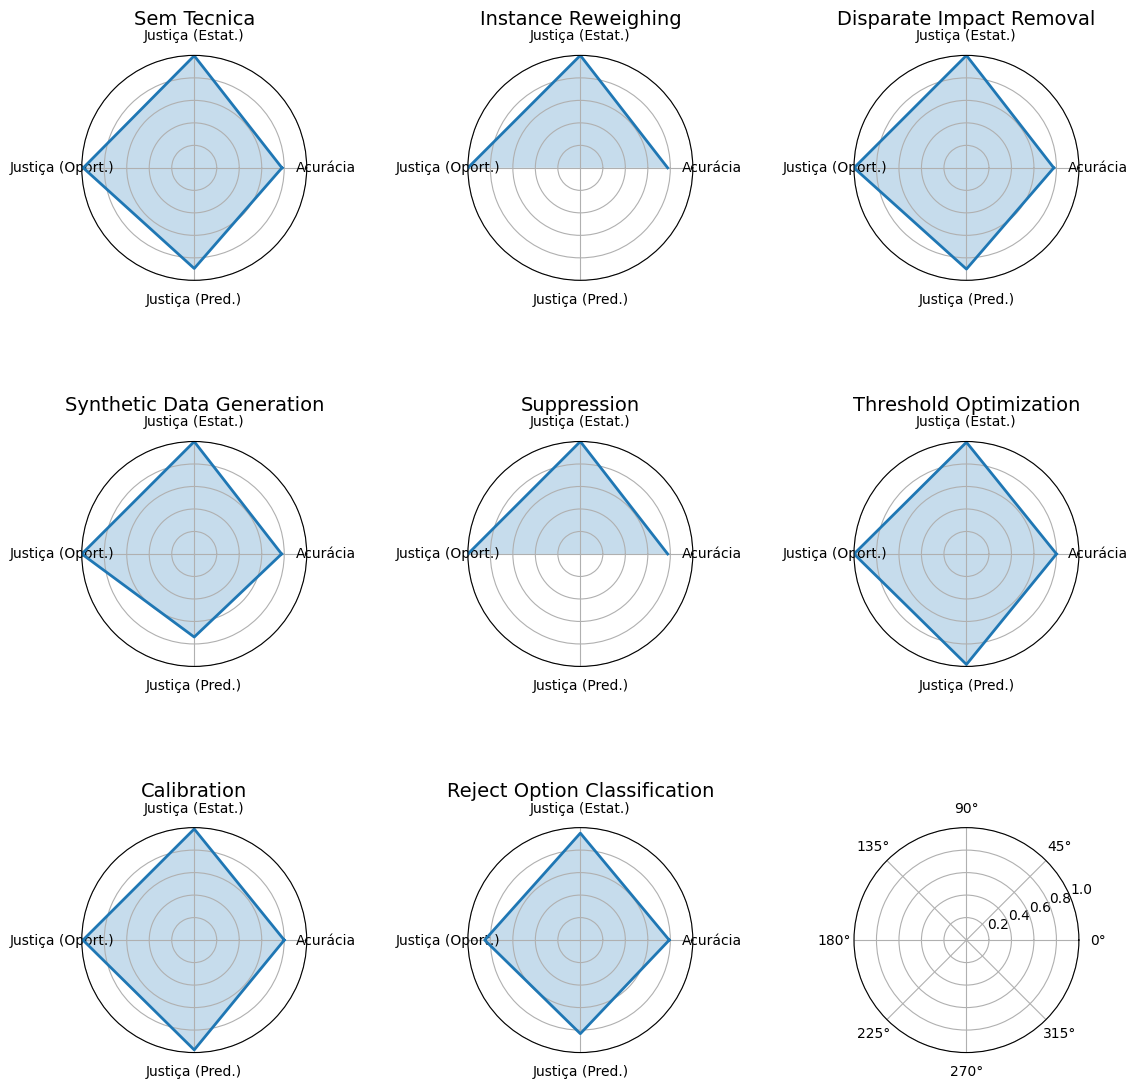

In [ ]:
grafico_radar(resultado_global['dataset_1_original_com_sensitive_age']['perceptron'])

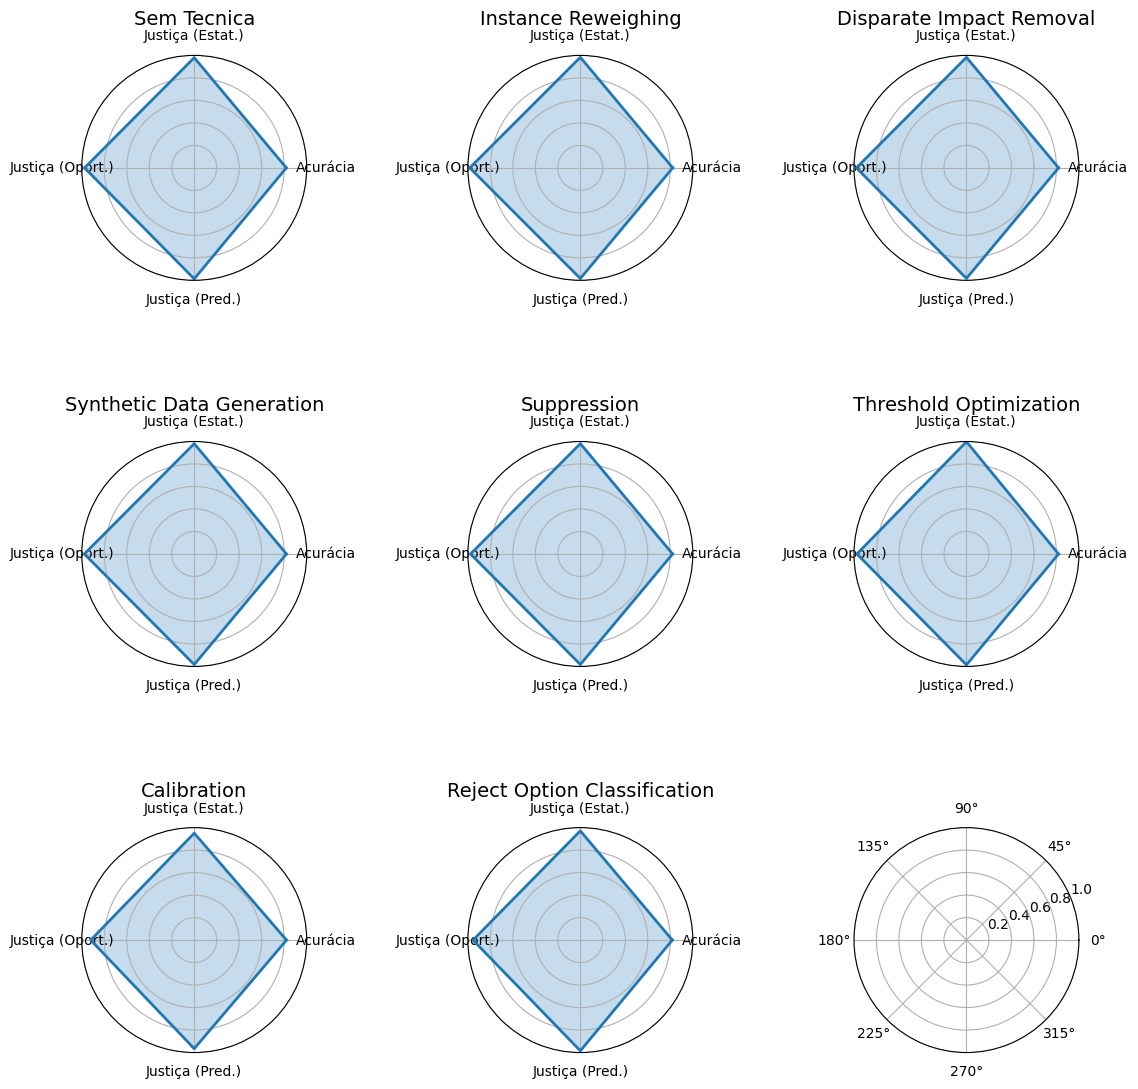

In [ ]:
grafico_radar(resultado_global['dataset_1_original']["random_forest"])

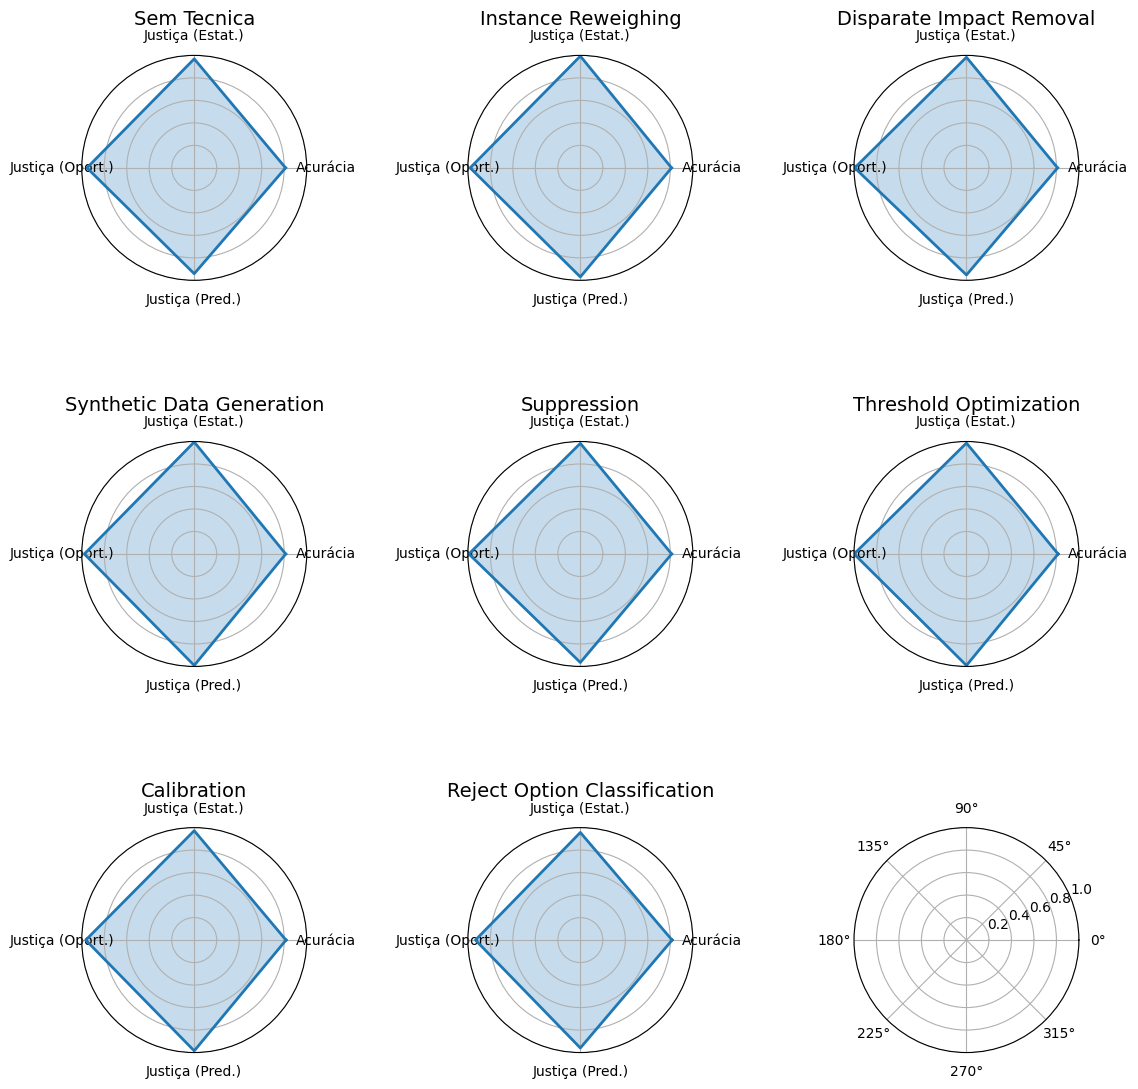

In [ ]:
grafico_radar(resultado_global['dataset_1_original']["regressão_logística"])

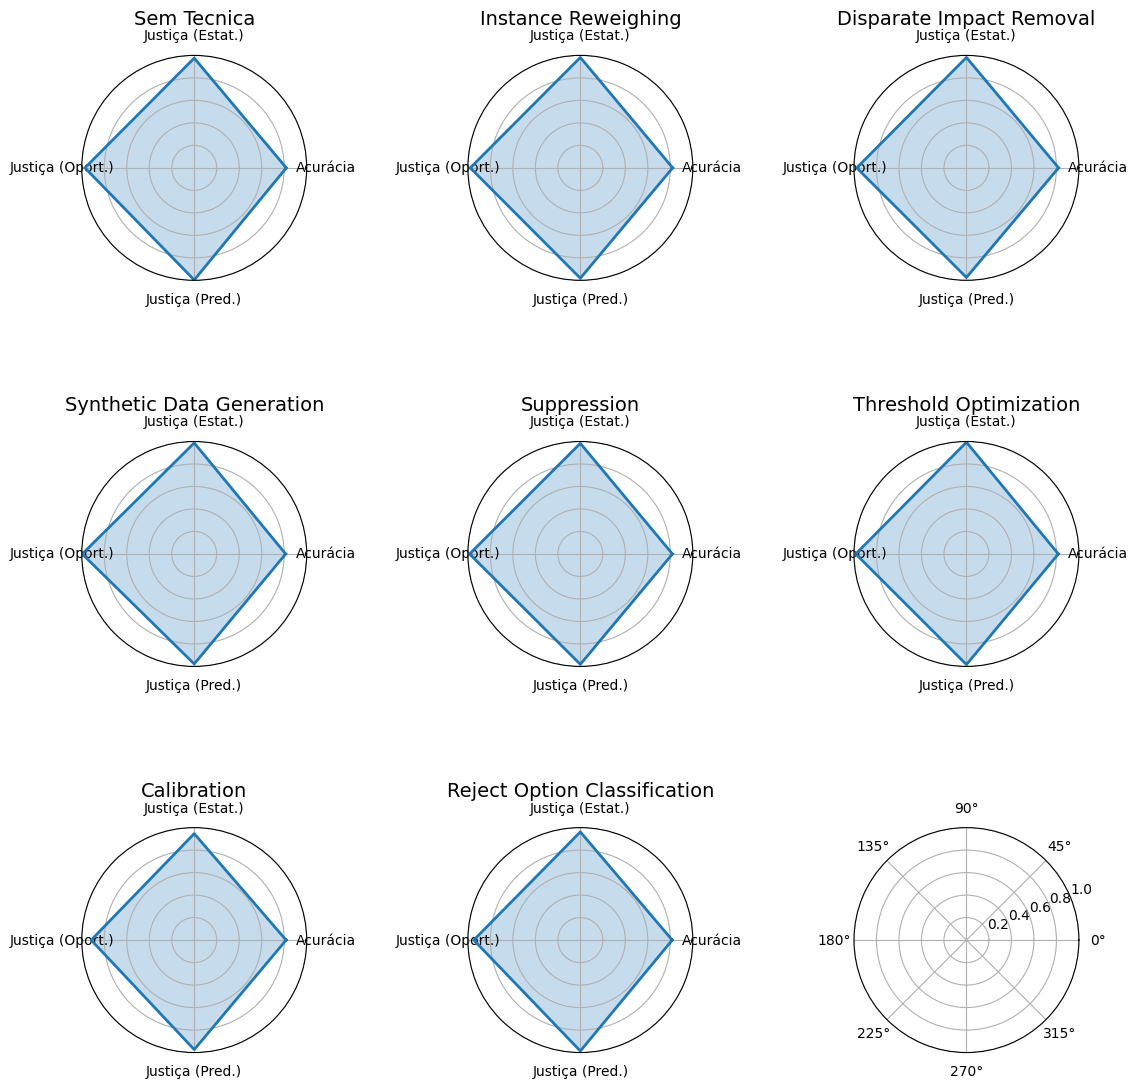

In [ ]:
grafico_radar(resultado_global['dataset_1_original']["xgboost"])